# Check consistency with julia script - Q,K,V from Julia

In [1]:
# imports
import numpy as np
import torch
import os
import sys
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)

from plm_gen_methods import generate_plm_n_save, generate_coords_n_save, generate_plm_vect_n_save
from seq_utils import read_tensor_from_txt, set_seed, letters_to_nums, modify_seq, find_target_seq, sequences_from_fasta
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
sys.path.pop(0)  # Removes the parent_dir from sys.path


'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM'

In [ ]:
def load_train_seqs_num(mac=True):
    family = 'jdoms_bacteria_train2'
    family = 'PF/PF00014'
    file_test_data = f'{family}.fasta'
    #filename = cwd + f'\CODE\DataAttentionDCA\jdoms\{family}.fasta'
    if not mac:
        file_test_data = r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
    train_sequences = sequences_from_fasta(file_test_data)
    train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
    # remove non capital letters - '-' considered as capital letter
    train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
    train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
    print(f"Loaded {len(train_sequences)} training sequences from {file_test_data}")
    return train_sequences_num
train_seqs = load_train_seqs_num(mac=True)
# count length of sequences avg
seq_lengths = [len(seq) for seq in train_seqs]
print(f"Average length of sequences: {np.mean(seq_lengths)}")
train_seqs = np.array(train_seqs)
print(train_seqs.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'JDOMS.fasta'

In [5]:
import numpy as np
Jtens = np.load('PF/J_tensor.npy')
print(Jtens.shape)

(21, 21, 53, 53)


In [ ]:
save_dir = 'Jutlia_test_Jload'
#Nbins=35
Nseqs=1000
b = 1
#target = (14, 12)  # Example target coordinates
init_sequence = 1000
save_name = f'gen_{init_sequence}_{Nseqs}_{b}'
generated_sequences = generate_plm_vect_n_save(save_dir, save_name, Jtens, init_sequence=init_sequence, n_iter=Nseqs, beta=b, beta_PCA=0)

Generated 1000 sequences.
train_seqs: 4915
shapes: (1000, 53)


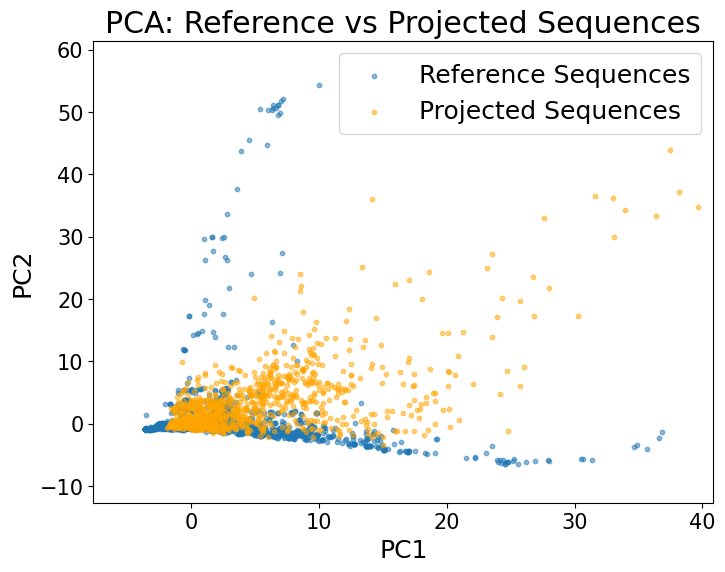

In [9]:
# load generated sequences
gen_seqs = np.load(os.path.join(save_dir, f'{save_name}.npy'))
print(f"Generated {len(gen_seqs)} sequences.")
print("train_seqs:", len(train_seqs))
print("shapes:", gen_seqs.shape)
# keep only first 53 columns of train_seqs
train_seqs = train_seqs[:, :53]
plot_projected_pca(train_seqs,gen_seqs)

# WITH JDOMS

In [39]:
J_jl = np.load('J_tensor.npy')
print(J.shape)

(21, 21, 63, 63)


In [31]:
# load J_tens from Q,K,V in results
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from dcascore import attention_heads_from_model

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_youss/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_youss/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_youss/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]
model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
print(f"Q shape: {Q_1.shape}, K shape: {K_1.shape}, V shape: {V_1.shape}")
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)
i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
W = W * mask
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)


/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src
Current directory: /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST
Q shape: torch.Size([64, 10, 63]), K shape: torch.Size([64, 10, 63]), V shape: torch.Size([64, 21, 21])
torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [38]:
Jtens_py = load_J_tensor()

Q shape: torch.Size([64, 10, 63]), K shape: torch.Size([64, 10, 63]), V shape: torch.Size([64, 21, 21])
torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [37]:
# compare the two J tensors
print("Jtens shape:", Jtens.shape)
print("J shape:", J.shape)
# variance
print("Variance of Jtens:", Jtens.var())
print("Variance of J:", J.var())
print("Max of Jtens:", Jtens.max())
print("Max of J:", J.max())
print("Min of Jtens:", Jtens.min())
print("Min of J:", J.min())
print("Mean of Jtens:", Jtens.mean())
print("Mean of J:", J.mean())

diff = Jtens - J
print("mean absolute difference:", np.abs(diff).mean())

Jtens shape: torch.Size([21, 21, 63, 63])
J shape: (21, 21, 63, 63)
Variance of Jtens: tensor(0.0038)
Variance of J: 0.0034603324611349
Max of Jtens: tensor(3.3160)
Max of J: 3.1656359726692744
Min of Jtens: tensor(-1.4643)
Min of J: -1.4076657484107817
Mean of Jtens: tensor(-6.1416e-05)
Mean of J: -4.344794785522537e-05
mean absolute difference: tensor(0.0505, dtype=torch.float64)


/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_58641/2702696328.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = Jtens - J
/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_58641/2702696328.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print("mean absolute difference:", np.abs(diff).mean())


In [63]:
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from seq_utils import load_train_seqs
from Frquencies_plot_func import plot_frequencies_aa_pos,plot_corr_aa_pos
sys.path.pop(0)  # Removes the parent_dir from sys.path

train_seqs = load_train_seqs(mac=True) 
train_seqs_num = [letters_to_nums(seq) for seq in train_seqs]
train_seqs_num = np.array(train_seqs_num)
print(train_seqs_num.shape)

Loaded 14502 training sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta
(14502, 63)


In [ ]:
save_dir = 'jdoms_J_jl'
#Nbins=35
Nseqs=3000
b = 1
#target = (14, 12)  # Example target coordinates
init_sequence = 3000
save_name = f'gen_{init_sequence}_{Nseqs}_{b}'
generated_sequences = generate_plm_vect_n_save(save_dir, save_name, J_jl, init_sequence=init_sequence, n_iter=Nseqs, beta=b, beta_PCA=0)

Generated 3000 sequences.
train_seqs: 14502
shapes: (3000, 63)


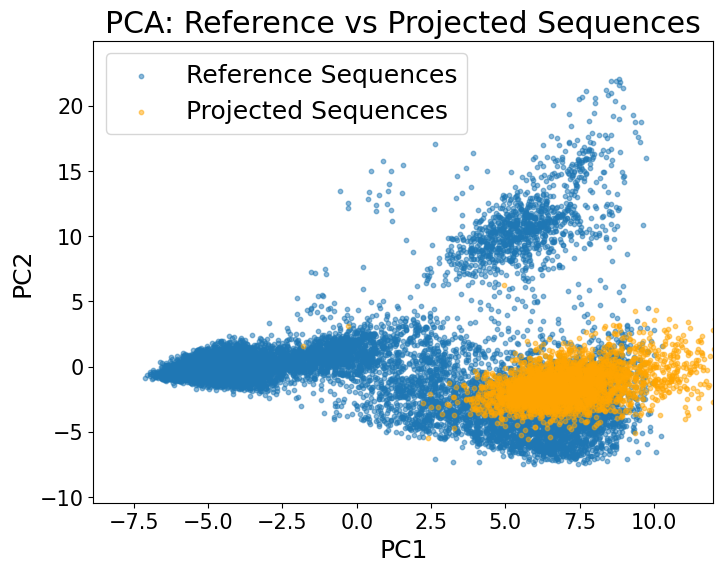

In [50]:
# load generated sequences
gen_seqs_jl = np.load(os.path.join(save_dir, f'{save_name}.npy'))
print(f"Generated {len(gen_seqs_jl)} sequences.")
print("train_seqs:", len(train_seqs))
print("shapes:", gen_seqs_jl.shape)
# keep only first 53 columns of train_seqs
plot_projected_pca(train_seqs,gen_seqs_jl)

In [ ]:
save_dir = 'jdoms_J_py'
#Nbins=35
Nseqs=3000
b = 1
#target = (14, 12)  # Example target coordinates
init_sequence = 3000
save_name = f'gen_{init_sequence}_{Nseqs}_{b}'
generated_sequences = generate_plm_vect_n_save(save_dir, save_name, Jtens_py, init_sequence=init_sequence, n_iter=Nseqs, beta=b, beta_PCA=0)

Generated 3000 sequences.
train_seqs: 14502
shapes: (3000, 63)


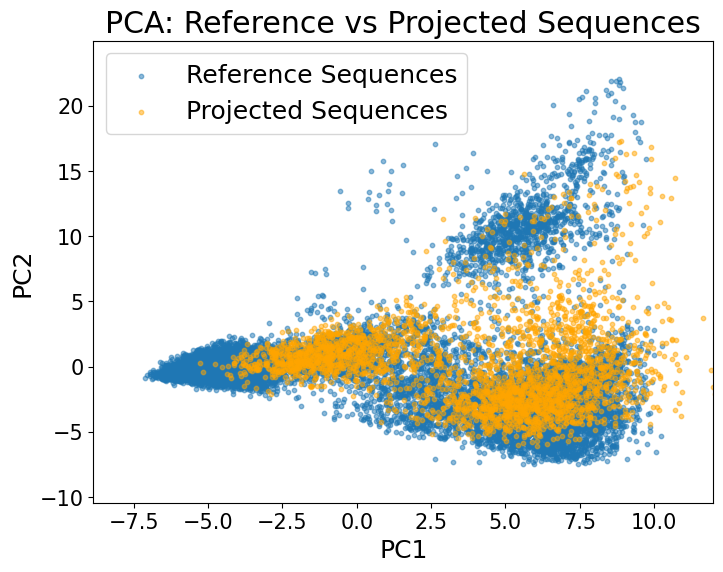

In [52]:
# load generated sequences
gen_seqs_py = np.load(os.path.join(save_dir, f'{save_name}.npy'))
print(f"Generated {len(gen_seqs_py)} sequences.")
print("train_seqs:", len(train_seqs))
print("shapes:", gen_seqs_py.shape)
# keep only first 53 columns of train_seqs
plot_projected_pca(train_seqs,gen_seqs_py)

## FREQS

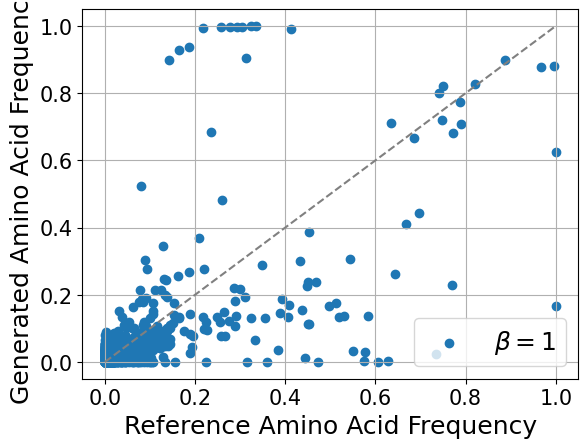

In [64]:
save_path = 'jdoms_J_jl'
plot_frequencies_aa_pos(gen_seqs_jl,train_seqs_num,beta=b)
#plot_corr_aa_pos(gen_seqs_jl,np.array(train_seqs_num))

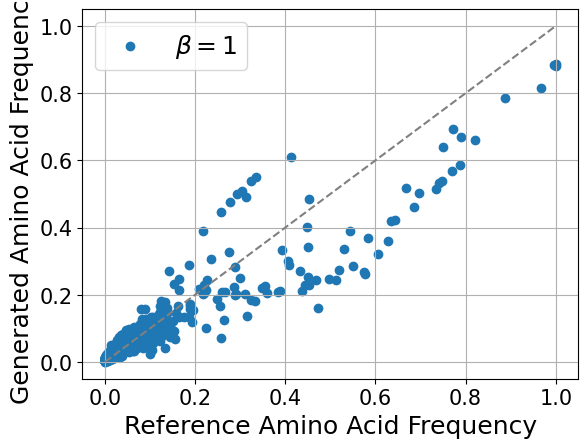

In [65]:
save_path = 'jdoms_J_py'
plot_frequencies_aa_pos(gen_seqs_py,train_seqs_num,beta=b)
#plot_corr_aa_pos(gen_seqs_jl,np.array(train_seqs_num))

In [4]:
# load J_tens from Q,K,V in results
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from dcascore import attention_heads_from_model

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = os.getcwd()
Q_1 = read_tensor_from_txt( cwd +"/JDOMS/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/JDOMS/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/JDOMS/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]
model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
print(f"Q shape: {Q_1.shape}, K shape: {K_1.shape}, V shape: {V_1.shape}")
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)
i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
W = W * mask
# Compute Jtens
Jtens_ale = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens_ale.shape[0]
N = Jtens_ale.shape[2]
print(q)
print(N)
print(Jtens_ale.shape)


/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src
Current directory: /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST


ValueError: invalid literal for int() with base 10: '0.9823974526998731'